# Import Packages

In [2]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using OrdinaryDiffEq
Random.seed!(145975);
using KernelDensity
using LaTeXStrings
using StatsBase
using JLD2
using HypothesisTests
using LaTeXStrings
using Trapz
using DataFrames, GLM, StatsBase
using Polynomials 
using Trapz
using EasyFit
using LsqFit
using ColorSchemes
using Pandas


# NADH

In [6]:
allDatNADH = JLD2.load("NAD_ProcData_nmoleper1M.jld")
NAD1mil_NC = allDatNADH["NAD1mil_NC"];
NADH1mil_NC = allDatNADH["NADH1mil_NC"];
NADH1mil_C = allDatNADH["NADH1mil_C"];
NAD1mil_C = allDatNADH["NAD1mil_C"];

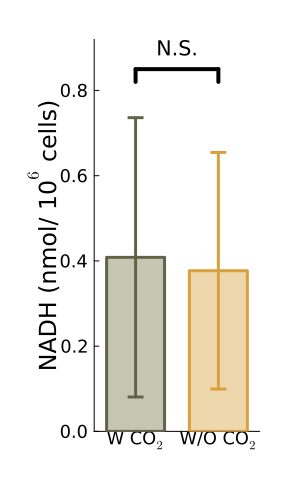

In [54]:
bbb = bar(transpose([1,2]), transpose([mean(NADH1mil_C), mean(NADH1mil_NC)]), yerror = transpose([std(NADH1mil_C), std(NADH1mil_NC)]),
        label = "", grid = false, ylabel = "NADH (nmol/ 10"*L"^6"*" cells)", xlabel = "", linewidth = 3, xticks = ([1,2], ["W CO"*L"_2", "W/O CO"*L"_2"]), 
    colour = ["#c5c6b1ff" "#efd7adff"], linecolour = ["#616247ff" "#daa03dff"], markercolour = ["#616247ff" "#daa03dff"], markersize=8, bar_width = 0.7, xlim = (0.5,2.5))


plot!([1,2],[3.6,3.6].-2.75, label = "", colour = "black", width = 4, ylim = (0,0.92))
plot!([1,1],[3.57,3.6].-2.75, label = "", colour = "black", width = 4)
plot!([2,2],[3.57,3.6].-2.75, label = "", colour = "black", width = 4)

pvs = pvalue(EqualVarianceTTest(vec(convert.(Float64, NADH1mil_C)), vec(convert.(Float64, NADH1mil_NC))))

if pvs > 0.05
    sg = "N.S."
elseif 0.05 >= pvs > 0.01
    sg = "*"
elseif 0.01 >= pvs > 0.001
    sg = "**"
end

annotate!(mean([1,2]), 0.9, sg, 14)


pp1 = Plots.plot(bbb, size = (300,500), margin = 8mm, xguidefontsize=16, yguidefontsize=16, tickfontsize=12)

In [80]:
mean(NADH1mil_C) / mean(NADH1mil_NC)

1.0833812535940195

In [81]:
mean(NADH1mil_C) \ mean(NADH1mil_NC)

0.9230360934182591

# MCT1

In [36]:
# df = read_pickle("C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/ProcessedData.pkl");
df = read_pickle("C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/ProcessedData_femtomolPer1Mil.pkl");

df

Dict{Any, Any} with 2 entries:
  "CO2"   => [28.9528, 11.1628, 14.5148, 12.6672, 12.1839, 19.2441, 13.961, 8.8…
  "NoCO2" => [20.0075, 23.1498, 23.1498, 10.9478, 27.3117, 11.0548, 12.6672, 11…

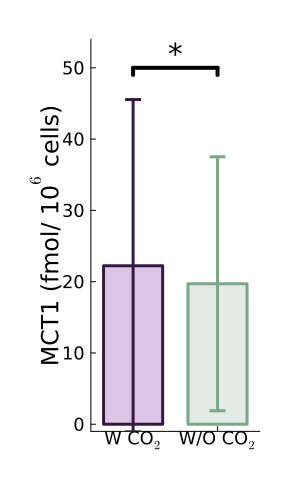

In [53]:
bbb = bar(transpose([1,2]), transpose([mean(df["CO2"]), mean(df["NoCO2"])]), yerror = transpose([std(df["CO2"]), std(df["NoCO2"])]),
        label = "", grid = false, ylabel = "MCT1 (fmol/ 10"*L"^6"*" cells)", xlabel = "", linewidth = 3, xticks = ([1,2], ["W CO"*L"_2", "W/O CO"*L"_2"]), 
    colour = ["#dbc4e6ff" "#e2ebe5ff"], linecolour = ["#331B3F" "#7ba687ff"], markercolour = ["#331B3F" "#7ba687ff"], markersize=8, bar_width = 0.7, xlim = (0.5,2.5))

colour = ["#dbc4e6ff" "#e2ebe5ff"]

plot!([1,2],[50, 50], label = "", colour = "black", width = 4, ylim = (-1,54))
plot!([1,1],[50,49], label = "", colour = "black", width = 4)
plot!([2,2],[50,49], label = "", colour = "black", width = 4)

pvs = pvalue(EqualVarianceTTest(vec(convert.(Float64, df["CO2"])), vec(convert.(Float64, df["NoCO2"]))))

if pvs > 0.05
    sg = "N.S."
elseif 0.05 >= pvs > 0.01
    sg = "*"
elseif 0.01 >= pvs > 0.001
    sg = "**"
end

annotate!(mean([1,2]), 52, sg, 20)

pp2=Plots.plot(bbb, size = (300,500), margin = 8mm, xguidefontsize=16, yguidefontsize=16, tickfontsize=12)

In [82]:
mean(df["CO2"]) / mean(df["NoCO2"])

1.1285017523184586

In [83]:
mean(df["CO2"]) \ mean(df["NoCO2"])

0.8861306577021637

# pH

In [55]:
pHDat = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\NoCO2Asseys\\pH.csv", DataFrames.DataFrame))

6×2 Matrix{Float64}:
 7.31  9.02
 7.38  9.01
 7.33  9.01
 7.42  9.0
 7.43  9.03
 7.43  9.09

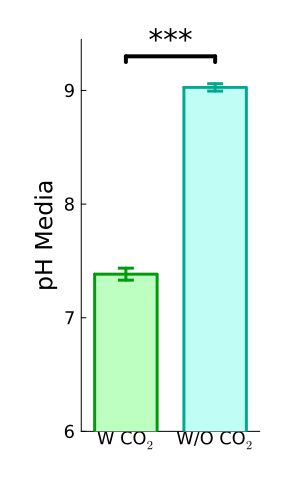

In [60]:
bbb = bar(transpose([1,2]), transpose([mean(pHDat[:,1]), mean(pHDat[:,2])]), yerror = transpose([std(pHDat[:,1]), std(pHDat[:,2])]),
        label = "", grid = false, ylabel = "pH Media", xlabel = "", linewidth = 3, xticks = ([1,2], ["W CO"*L"_2", "W/O CO"*L"_2"]), bar_width = 0.7, xlim = (0.5,2.5), 
    colour = ["#bdfec1ff" "#c0fef5ff"], linecolour = ["#029b0bff" "#02a98fff"], markercolour = ["#029b0bff" "#02a98fff"], markersize=8, ylim=(6,9.45))


plot!([1,2],[9.3,9.3], label = "", colour = "black", width = 4)
plot!([1,1],[9.25,9.3], label = "", colour = "black", width = 4)
plot!([2,2],[9.25,9.3], label = "", colour = "black", width = 4)

pvs = pvalue(UnequalVarianceTTest(vec(convert.(Float64, pHDat[:,1])), vec(convert.(Float64, pHDat[:,2]))))

if pvs > 0.05
    sg = "N.S."
elseif 0.05 >= pvs > 0.01
    sg = "*"
elseif 0.01 >= pvs > 0.001
    sg = "**"
elseif pvs <= 0.001
    sg = "***"
end

annotate!(mean([1,2]), 9.45, sg, 20)

pp3=Plots.plot(bbb, size = (300,500), margin = 8mm, xguidefontsize=16, yguidefontsize=16, tickfontsize=12)

In [84]:
mean(pHDat[:,1]) / mean(pHDat[:,2])

0.81794682422452

In [85]:
mean(pHDat[:,1]) \ mean(pHDat[:,2])

1.222573363431151

# LDH

In [61]:
df2 = read_pickle("C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/LDH/ProcessedData_femtomolePer1Mil.pkl");
df2

Dict{Any, Any} with 2 entries:
  "CO2"   => [187.378, 307.504, 192.332, 232.875, 194.012, 297.006, 274.674, 16…
  "NoCO2" => [187.378, 307.504, 192.332, 232.875, 194.012, 297.006, 274.674, 16…

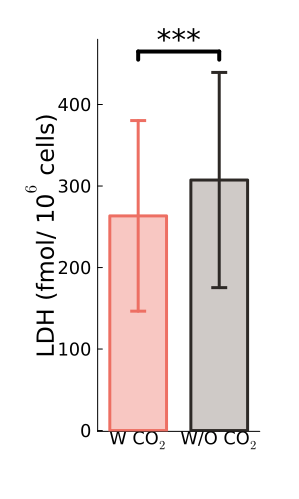

In [79]:
bbb = bar(transpose([1,2]), transpose([mean(df2["CO2"]), mean(df2["NoCO2"])]), yerror = transpose([std(df2["CO2"]), std(df2["NoCO2"])]),
        label = "", grid = false, ylabel = "LDH (fmol/ 10"*L"^6"*" cells)", xlabel = "", linewidth = 3, xticks = ([1,2], ["W CO"*L"_2", "W/O CO"*L"_2"]), 
    colour = ["#f8c7c2ff" "#cfcac7ff"], linecolour = ["#ed6f63" "#2D2926"], markercolour = ["#ed6f63" "#2D2926"], markersize=8, bar_width = 0.7, xlim = (0.5,2.5))

plot!([1,2],[465, 465], label = "", colour = "black", width = 4, ylim = (-1,480))
plot!([1,1],[465,455], label = "", colour = "black", width = 4)
plot!([2,2],[465,455], label = "", colour = "black", width = 4)

pvs = pvalue(EqualVarianceTTest(vec(convert.(Float64, df2["CO2"])), vec(convert.(Float64, df2["NoCO2"]))))

if pvs > 0.05
    sg = "N.S."
elseif 0.05 >= pvs > 0.01
    sg = "*"
elseif 0.01 >= pvs > 0.001
    sg = "**"
end

annotate!(mean([1,2]), 480, sg, 20)

pp4 = Plots.plot(bbb, size = (300,500), margin = 8mm, xguidefontsize=16, yguidefontsize=16, tickfontsize=12)

In [86]:
mean(df2["CO2"]) / mean(df2["NoCO2"])

0.8568803422177429

In [87]:
mean(df2["CO2"]) \ mean(df2["NoCO2"])

1.1670240881146143

# Final Plot

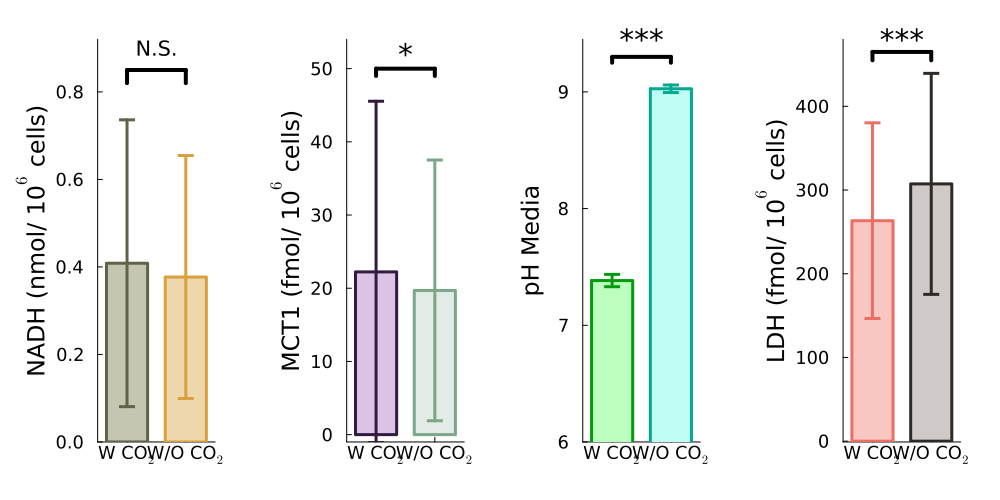

In [88]:
FPP = Plots.plot(pp1, pp2, pp3, pp4,  layout=grid(1,4), size = (1000,500))

savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure2Stuff\\NoCO2Tests.svg")

display(FPP)

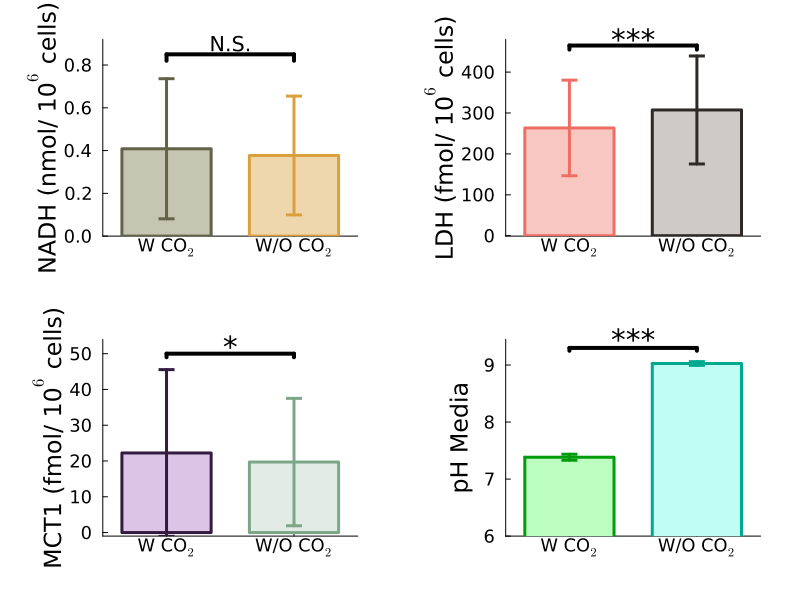

In [91]:
FPP = Plots.plot(pp1, pp4, pp2, pp3,  layout=grid(2,2), size = (800,600))

savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure2Stuff\\NoCO2Tests_2x2.svg")

display(FPP)